In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings


In [2]:


# Load the engineered dataset
df_engineered = pd.read_parquet('results/df_engineered.parquet')

print(f"\nDataset shape: {df_engineered.shape}")



Dataset shape: (204942, 79)


In [3]:
df_engineered.head()

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_freq_MHz_missing,PCell_E-ARFCN_missing,device_pc1,device_pc2,device_pc3,device_pc4,direction_uplink,measured_qos_delay,hour,day_of_week
216,2021-06-22 09:49:54+02:00,NaN,68700000.0,0.000848,52.514013,13.335172,41.9,0.0,0.0,0.0652,...,0,0,1,0,0,0,0,0,9,1
217,2021-06-22 09:49:54+02:00,NaN,24500000.0,0.000512,52.514008,13.335195,35.3,0.0,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
218,2021-06-22 09:49:54+02:00,NaN,49800000.0,0.000090,52.513830,13.334935,30.7,0.0,0.0,0.0653,...,0,0,0,0,1,0,0,0,9,1
219,2021-06-22 09:49:54+02:00,1396.0,70500000.0,0.000207,52.513848,13.334832,32.3,0.0,265.9,0.0653,...,0,0,0,0,0,1,0,0,9,1
220,2021-06-22 09:49:55+02:00,NaN,20800000.0,0.002268,52.514005,13.335195,35.4,0.0,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1


In [4]:
# Missing percentage for each feature in df_engineered
feature_missing_pct = (
    df_engineered.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

# Convert to a feature list with percentages
feature_missing_list = [
    {"feature": col, "missing_pct": pct}
    for col, pct in feature_missing_pct.items()
]

# Optional: DataFrame view
feature_missing_df = pd.DataFrame(feature_missing_list)

feature_missing_df

,feature,missing_pct
0,ping_ms,28.16
1,datarate,7.65
2,jitter,7.65
3,Pos in Ref Round,6.91
4,PCell_Downlink_bandwidth_MHz,6.15
...,...,...
74,datarate_missing,0.00
75,jitter_missing,0.00
76,Pos in Ref Round_missing,0.00
77,PCell_Cell_Identity_missing,0.00


In [5]:
df_engineered

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_freq_MHz_missing,PCell_E-ARFCN_missing,device_pc1,device_pc2,device_pc3,device_pc4,direction_uplink,measured_qos_delay,hour,day_of_week
216,2021-06-22 09:49:54+02:00,NaN,68700000.0,0.000848,52.514013,13.335172,41.9,0.0000,0.0,0.0652,...,0,0,1,0,0,0,0,0,9,1
217,2021-06-22 09:49:54+02:00,NaN,24500000.0,0.000512,52.514008,13.335195,35.3,0.0000,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
218,2021-06-22 09:49:54+02:00,NaN,49800000.0,0.000090,52.513830,13.334935,30.7,0.0000,0.0,0.0653,...,0,0,0,0,1,0,0,0,9,1
219,2021-06-22 09:49:54+02:00,1396.0,70500000.0,0.000207,52.513848,13.334832,32.3,0.0000,265.9,0.0653,...,0,0,0,0,0,1,0,0,9,1
220,2021-06-22 09:49:55+02:00,NaN,20800000.0,0.002268,52.514005,13.335195,35.4,0.0000,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207429,2021-06-24 18:59:55+02:00,NaN,178000000.0,0.000123,52.513883,13.335023,28.0,2.7780,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207430,2021-06-24 18:59:56+02:00,NaN,178000000.0,0.000091,52.513885,13.335027,28.0,0.7408,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207431,2021-06-24 18:59:57+02:00,NaN,165000000.0,0.000076,52.513887,13.335030,28.1,0.0000,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207432,2021-06-24 18:59:58+02:00,540.0,177000000.0,0.000040,52.513890,13.335032,28.1,0.0000,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3


In [6]:
remove_from_imputation = [
    'PCell_Cell_Identity',    
    'PCell_TAC',                 
    'PCell_E-ARFCN','PCell_Uplink_frequency','PCell_Cell_ID'
]

In [7]:
df_engineered = df_engineered.drop(columns=remove_from_imputation)

In [8]:


log_features = [
    'datarate',
    'target_datarate',
    'PCell_Downlink_TB_Size',
    'PCell_Uplink_TB_Size',
    'PCell_DL_RBs_MCS_Low', 
    'PCell_DL_RBs_MCS_Mid', 'PCell_DL_RBs_MCS_High',
    'PCell_Downlink_Num_RBs', 'PCell_Uplink_Num_RBs'
    ,'ping_ms','Pos in Ref Round','Traffic Distance','speed_kmh','PCell_Uplink_Tx_Power_(dBm)'
]

print(f"\nApplying log(x+1) to {len(log_features)} features...")

for feat in log_features:
    if feat in df_engineered.columns:
        # Before
        before = df_engineered[feat].dropna()
        print(f"\n{feat}:")
        print(f"  Before: min={before.min():.0f}, max={before.max():.0f}")
        
        # Apply log(x + 1)
        df_engineered[feat] = np.log1p(df_engineered[feat])
        
        # After
        after = df_engineered[feat].dropna()
        print(f"  After:  min={after.min():.2f}, max={after.max():.2f}")





Applying log(x+1) to 14 features...

datarate:
  Before: min=851, max=271000000
  After:  min=6.75, max=19.42

target_datarate:
  Before: min=400000, max=350000000
  After:  min=12.90, max=19.67

PCell_Downlink_TB_Size:
  Before: min=7, max=18679098
  After:  min=2.08, max=16.74

PCell_Uplink_TB_Size:
  Before: min=0, max=6211206
  After:  min=0.00, max=15.64

PCell_DL_RBs_MCS_Low:
  Before: min=0, max=92588
  After:  min=0.00, max=11.44

PCell_DL_RBs_MCS_Mid:
  Before: min=0, max=95920
  After:  min=0.00, max=11.47

PCell_DL_RBs_MCS_High:
  Before: min=0, max=100376
  After:  min=0.00, max=11.52

PCell_Downlink_Num_RBs:
  Before: min=1, max=100580
  After:  min=0.69, max=11.52

PCell_Uplink_Num_RBs:
  Before: min=1, max=94359
  After:  min=0.69, max=11.45

ping_ms:
  Before: min=16, max=110676
  After:  min=2.83, max=11.61

Pos in Ref Round:
  Before: min=0, max=17319
  After:  min=0.00, max=9.76

Traffic Distance:
  Before: min=0, max=268
  After:  min=0.00, max=5.60

speed_kmh:
  B

In [9]:
df_engineered[log_features]

,datarate,target_datarate,PCell_Downlink_TB_Size,PCell_Uplink_TB_Size,PCell_DL_RBs_MCS_Low,PCell_DL_RBs_MCS_Mid,PCell_DL_RBs_MCS_High,PCell_Downlink_Num_RBs,PCell_Uplink_Num_RBs,ping_ms,Pos in Ref Round,Traffic Distance,speed_kmh,PCell_Uplink_Tx_Power_(dBm)
216,18.045260,19.673444,15.293008,7.726654,3.367296,0.000000,10.305179,10.306115,6.063785,NaN,NaN,3.953266,0.000000,4.720503
217,17.014184,19.673444,14.667208,9.902787,4.653960,7.403670,10.591497,10.634412,6.287859,NaN,NaN,3.920668,0.000000,1.540715
218,17.723526,19.673444,14.897844,10.036925,2.564949,8.722091,10.536274,10.687503,6.204558,NaN,NaN,3.585666,0.000000,2.404548
219,18.071123,19.673444,15.028756,7.693026,2.833213,4.262680,10.322329,10.325154,6.040255,7.242082,NaN,3.716122,0.000000,4.809736
220,16.850464,19.673444,14.227611,9.690047,4.653960,7.603399,10.172827,10.250264,6.068426,NaN,NaN,3.918528,0.000000,1.664227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207429,18.997294,19.673444,15.964078,7.651596,4.158883,0.000000,10.986343,10.987409,5.476464,NaN,NaN,3.687761,1.329195,4.726409
207430,18.997294,19.673444,15.785832,7.871311,2.079442,0.000000,10.747294,10.747444,5.509388,NaN,NaN,3.691173,0.554345,4.713535
207431,18.921456,19.673444,15.736908,7.824446,4.454347,0.000000,10.763102,10.764900,5.505332,NaN,NaN,3.694615,0.000000,4.719067
207432,18.991660,19.673444,16.254759,7.827241,5.225747,0.000000,11.237778,11.240211,5.556828,6.293419,NaN,3.703097,0.000000,4.718305


##### Create a mising value indicator for non-OHE features

In [10]:
onehot_encode_feat= [
    'device_pc1','device_pc2','device_pc3','device_pc4',
    'direction_uplink', 'measured_qos_delay',
    'operator','timestamp','hour','day_of_week'
]

In [11]:
df_engineered[onehot_encode_feat]

,device_pc1,device_pc2,device_pc3,device_pc4,direction_uplink,measured_qos_delay,operator,timestamp,hour,day_of_week
216,1,0,0,0,0,0,0,2021-06-22 09:49:54+02:00,9,1
217,0,1,0,0,0,0,1,2021-06-22 09:49:54+02:00,9,1
218,0,0,1,0,0,0,1,2021-06-22 09:49:54+02:00,9,1
219,0,0,0,1,0,0,0,2021-06-22 09:49:54+02:00,9,1
220,0,1,0,0,0,0,1,2021-06-22 09:49:55+02:00,9,1
...,...,...,...,...,...,...,...,...,...,...
207429,1,0,0,0,0,0,0,2021-06-24 18:59:55+02:00,18,3
207430,1,0,0,0,0,0,0,2021-06-24 18:59:56+02:00,18,3
207431,1,0,0,0,0,0,0,2021-06-24 18:59:57+02:00,18,3
207432,1,0,0,0,0,0,0,2021-06-24 18:59:58+02:00,18,3


In [12]:
'''for col in [c for c in df_engineered.columns if c not in onehot_encode_feat]:
    missing_indicator = f"{col}_missing"
    df_engineered[missing_indicator] = df_engineered[col].isna().astype("int8")'''

    

'for col in [c for c in df_engineered.columns if c not in onehot_encode_feat]:\n    missing_indicator = f"{col}_missing"\n    df_engineered[missing_indicator] = df_engineered[col].isna().astype("int8")'

In [13]:
df_engineered

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_freq_MHz_missing,PCell_E-ARFCN_missing,device_pc1,device_pc2,device_pc3,device_pc4,direction_uplink,measured_qos_delay,hour,day_of_week
216,2021-06-22 09:49:54+02:00,NaN,18.045260,0.000848,52.514013,13.335172,41.9,0.000000,0.0,0.0652,...,0,0,1,0,0,0,0,0,9,1
217,2021-06-22 09:49:54+02:00,NaN,17.014184,0.000512,52.514008,13.335195,35.3,0.000000,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
218,2021-06-22 09:49:54+02:00,NaN,17.723526,0.000090,52.513830,13.334935,30.7,0.000000,0.0,0.0653,...,0,0,0,0,1,0,0,0,9,1
219,2021-06-22 09:49:54+02:00,7.242082,18.071123,0.000207,52.513848,13.334832,32.3,0.000000,265.9,0.0653,...,0,0,0,0,0,1,0,0,9,1
220,2021-06-22 09:49:55+02:00,NaN,16.850464,0.002268,52.514005,13.335195,35.4,0.000000,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207429,2021-06-24 18:59:55+02:00,NaN,18.997294,0.000123,52.513883,13.335023,28.0,1.329195,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207430,2021-06-24 18:59:56+02:00,NaN,18.997294,0.000091,52.513885,13.335027,28.0,0.554345,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207431,2021-06-24 18:59:57+02:00,NaN,18.921456,0.000076,52.513887,13.335030,28.1,0.000000,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3
207432,2021-06-24 18:59:58+02:00,6.293419,18.991660,0.000040,52.513890,13.335032,28.1,0.000000,81.6,0.3287,...,0,0,1,0,0,0,0,0,18,3


In [14]:
# Highly Error Vals
high_vals = [
    'PCell_freq_MHz','COG',
    'PCell_Uplink_Tx_Power_(dBm)','Traffic Distance',
    'speed_kmh'
]

In [15]:
df_engineered[high_vals]

,PCell_freq_MHz,COG,PCell_Uplink_Tx_Power_(dBm),Traffic Distance,speed_kmh
216,1800.0,0.0,4.720503,3.953266,0.000000
217,1800.0,259.0,1.540715,3.920668,0.000000
218,2600.0,0.0,2.404548,3.585666,0.000000
219,1800.0,265.9,4.809736,3.716122,0.000000
220,1800.0,259.0,1.664227,3.918528,0.000000
...,...,...,...,...,...
207429,1800.0,81.6,4.726409,3.687761,1.329195
207430,1800.0,81.6,4.713535,3.691173,0.554345
207431,1800.0,81.6,4.719067,3.694615,0.000000
207432,1800.0,81.6,4.718305,3.703097,0.000000


Columns not found in df_engineered: ['PCell_Cell_ID']


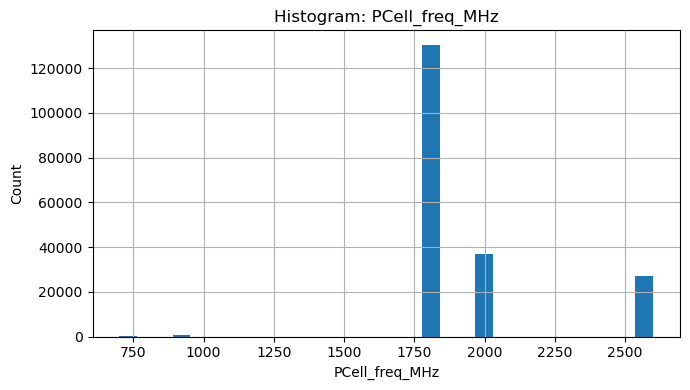

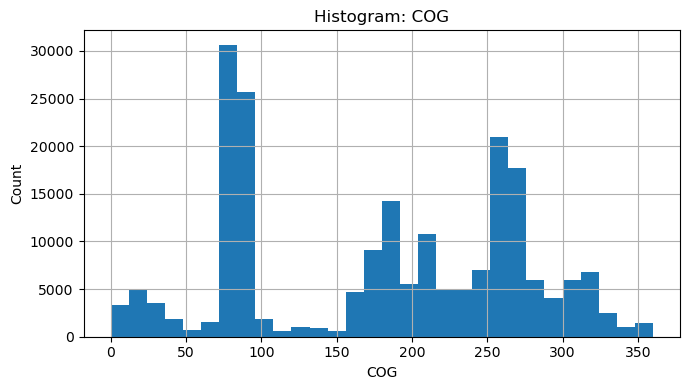

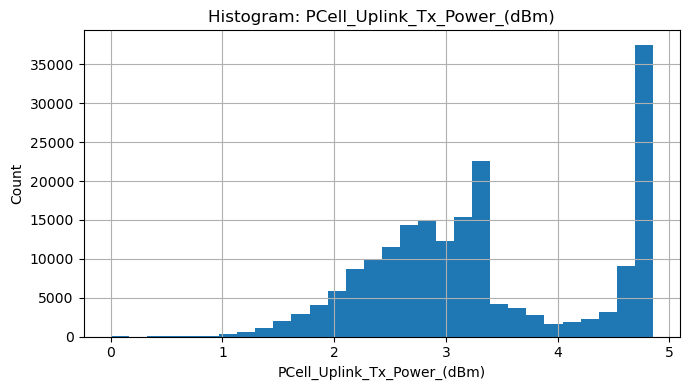

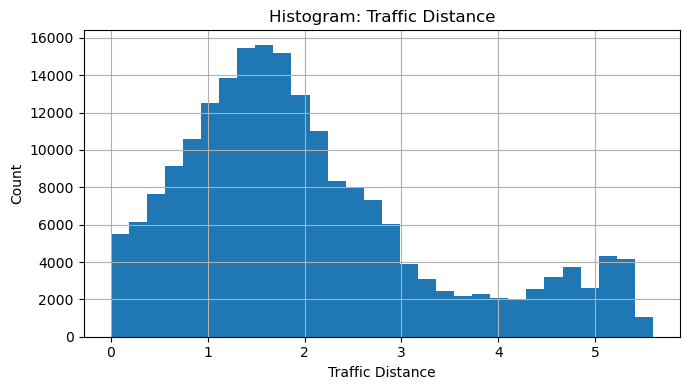

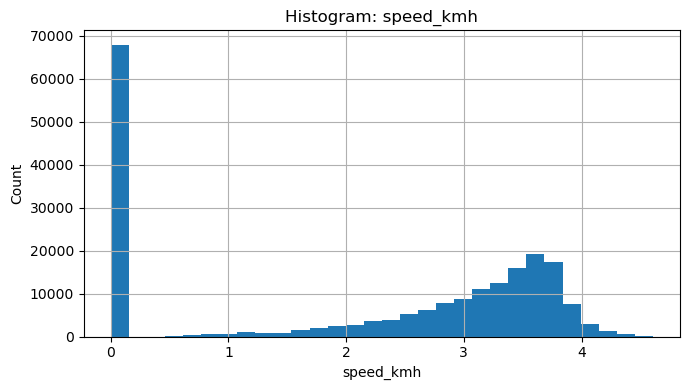

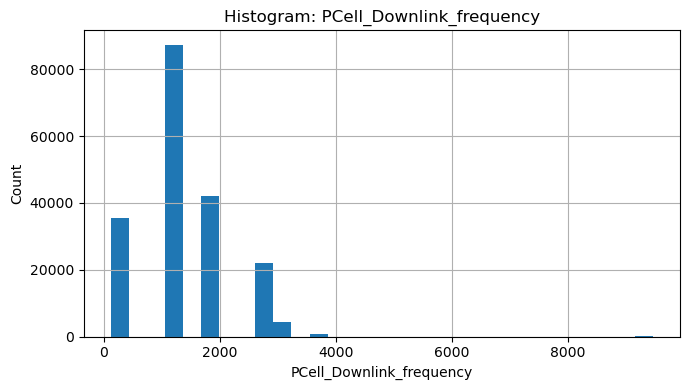

In [16]:
# Highly Error Vals
high_vals = [
    'PCell_Cell_ID', 'PCell_freq_MHz', 'COG',
    'PCell_Uplink_Tx_Power_(dBm)', 'Traffic Distance',
    'speed_kmh', 'PCell_Downlink_frequency'
]

available_cols = [c for c in high_vals if c in df_engineered.columns]
missing_cols = [c for c in high_vals if c not in df_engineered.columns]

if missing_cols:
    print("Columns not found in df_engineered:", missing_cols)

for col in available_cols:
    ax = df_engineered[col].dropna().hist(bins=30, figsize=(7, 4))
    ax.set_title(f'Histogram: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.figure.tight_layout()
    plt.show()


In [17]:
'''# One-hot encode
low_cad = ["PCell_Downlink_frequency","PCell_freq_MHz"]

# keep only columns that actually exist
cols_to_encode = [c for c in low_cad if c in df_engineered.columns]

df_engineered = pd.get_dummies(
    df_engineered,
    columns=cols_to_encode,
    dtype=int
)
df_engineered.columns'''

'# One-hot encode\nlow_cad = ["PCell_Downlink_frequency","PCell_freq_MHz"]\n\n# keep only columns that actually exist\ncols_to_encode = [c for c in low_cad if c in df_engineered.columns]\n\ndf_engineered = pd.get_dummies(\n    df_engineered,\n    columns=cols_to_encode,\n    dtype=int\n)\ndf_engineered.columns'

In [18]:
#df_engineered['PCell_Uplink_frequency'].value_counts()

In [19]:
#df_engineered['PCell_freq_MHz'].value_counts()

In [20]:
'''col = 'PCell_Downlink_frequency'
low, high = 0, 4000

s = pd.to_numeric(df_engineered[col], errors='coerce')
out_of_range = df_engineered[(s < low) | (s > high)]

print(f"Total rows: {len(df_engineered)}")
print(f"Non-null numeric {col}: {s.notna().sum()}")
print(f"Out-of-range rows (<{low} or >{high}): {len(out_of_range)}")

# Show sample offending values
display(out_of_range[[col]].head(5))

# Optional: exact distribution of offending values
print("\nOffending value counts:")
print(out_of_range[col].value_counts(dropna=False).head(20))'''

'col = \'PCell_Downlink_frequency\'\nlow, high = 0, 4000\n\ns = pd.to_numeric(df_engineered[col], errors=\'coerce\')\nout_of_range = df_engineered[(s < low) | (s > high)]\n\nprint(f"Total rows: {len(df_engineered)}")\nprint(f"Non-null numeric {col}: {s.notna().sum()}")\nprint(f"Out-of-range rows (<{low} or >{high}): {len(out_of_range)}")\n\n# Show sample offending values\ndisplay(out_of_range[[col]].head(5))\n\n# Optional: exact distribution of offending values\nprint("\nOffending value counts:")\nprint(out_of_range[col].value_counts(dropna=False).head(20))'

In [21]:
'''# Check out-of-range values for PCell_freq_MHz (outside 700 to 2700)
col = 'PCell_freq_MHz'
low, high = 700, 2700

s = pd.to_numeric(df_engineered[col], errors='coerce')
out_of_range = df_engineered[(s < low) | (s > high)]

print(f"Total rows: {len(df_engineered)}")
print(f"Non-null numeric {col}: {s.notna().sum()}")
print(f"Out-of-range rows (<{low} or >{high}): {len(out_of_range)}")

# Show sample offending values
display(out_of_range[[col]].head(20))

# Optional: exact distribution of offending values
print("\nOffending value counts:")
print(out_of_range[col].value_counts(dropna=False).head(20))'''


'# Check out-of-range values for PCell_freq_MHz (outside 700 to 2700)\ncol = \'PCell_freq_MHz\'\nlow, high = 700, 2700\n\ns = pd.to_numeric(df_engineered[col], errors=\'coerce\')\nout_of_range = df_engineered[(s < low) | (s > high)]\n\nprint(f"Total rows: {len(df_engineered)}")\nprint(f"Non-null numeric {col}: {s.notna().sum()}")\nprint(f"Out-of-range rows (<{low} or >{high}): {len(out_of_range)}")\n\n# Show sample offending values\ndisplay(out_of_range[[col]].head(20))\n\n# Optional: exact distribution of offending values\nprint("\nOffending value counts:")\nprint(out_of_range[col].value_counts(dropna=False).head(20))'

In [22]:
col = 'COG'
low, high = 0, 360

s = pd.to_numeric(df_engineered[col], errors='coerce')
out_of_range = df_engineered[(s < low) | (s > high)]

print(f"Total rows: {len(df_engineered)}")
print(f"Non-null numeric {col}: {s.notna().sum()}")
print(f"Out-of-range rows (<{low} or >{high}): {len(out_of_range)}")

# Show sample offending values
display(out_of_range[[col]].head(20))

# Optional: exact distribution of offending values
print("\nOffending value counts:")
print(out_of_range[col].value_counts(dropna=False).head(20))

Total rows: 204942
Non-null numeric COG: 204942
Out-of-range rows (<0 or >360): 0


,COG



Offending value counts:
Series([], Name: count, dtype: int64)


In [23]:
df_engineered.head()

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_freq_MHz_missing,PCell_E-ARFCN_missing,device_pc1,device_pc2,device_pc3,device_pc4,direction_uplink,measured_qos_delay,hour,day_of_week
216,2021-06-22 09:49:54+02:00,NaN,18.045260,0.000848,52.514013,13.335172,41.9,0.0,0.0,0.0652,...,0,0,1,0,0,0,0,0,9,1
217,2021-06-22 09:49:54+02:00,NaN,17.014184,0.000512,52.514008,13.335195,35.3,0.0,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1
218,2021-06-22 09:49:54+02:00,NaN,17.723526,0.000090,52.513830,13.334935,30.7,0.0,0.0,0.0653,...,0,0,0,0,1,0,0,0,9,1
219,2021-06-22 09:49:54+02:00,7.242082,18.071123,0.000207,52.513848,13.334832,32.3,0.0,265.9,0.0653,...,0,0,0,0,0,1,0,0,9,1
220,2021-06-22 09:49:55+02:00,NaN,16.850464,0.002268,52.514005,13.335195,35.4,0.0,259.0,0.0652,...,0,0,0,1,0,0,0,0,9,1


In [24]:

print("TEMPORAL SPLITTING STRATEGY")

# Check data distribution by date
df_engineered['date'] = df_engineered['timestamp'].dt.date

print("Data distribution by date:")
date_counts = df_engineered.groupby('date').size()
for date, count in date_counts.items():
    pct = (count / len(df_engineered)) * 100
    print(f"  {date}: {count:>7,} rows ({pct:>5.2f}%)")

print(f"\nTotal: {len(df_engineered):,} rows")

TEMPORAL SPLITTING STRATEGY
Data distribution by date:
  2021-06-22:  79,564 rows (38.82%)
  2021-06-23:  79,015 rows (38.55%)
  2021-06-24:  46,363 rows (22.62%)

Total: 204,942 rows


In [25]:

print("EXECUTING TEMPORAL SPLIT (70/15/15)")

# Sort by timestamp to ensure chronological order
df_sorted = df_engineered.sort_values('timestamp').reset_index(drop=True)

print(f"\nSorted by timestamp")
# Calculate split indices
n_total = len(df_sorted)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val  # Remainder goes to test

print(f"\n SPLIT SIZES:")
print(f"  Total:      {n_total:>7,} rows (100.0%)")
print(f"  Train:      {n_train:>7,} rows ({n_train/n_total*100:>5.1f}%)")
print(f"  Validation: {n_val:>7,} rows ({n_val/n_total*100:>5.1f}%)")
print(f"  Test:       {n_test:>7,} rows ({n_test/n_total*100:>5.1f}%)")

# Split the data
train_data = df_sorted.iloc[:n_train].copy()
val_data = df_sorted.iloc[n_train:n_train+n_val].copy()
test_data = df_sorted.iloc[n_train+n_val:].copy()

print(f"\n Data split complete")

# Verify temporal order (no leakage)
print(f"\nTEMPORAL VERIFICATION (No leakage check):")
print(f"  Train period:      {train_data['timestamp'].min()} to {train_data['timestamp'].max()}")
print(f"  Validation period: {val_data['timestamp'].min()} to {val_data['timestamp'].max()}")
print(f"  Test period:       {test_data['timestamp'].min()} to {test_data['timestamp'].max()}")

# Check no overlap
train_max = train_data['timestamp'].max()
val_min = val_data['timestamp'].min()
val_max = val_data['timestamp'].max()
test_min = test_data['timestamp'].min()

if train_max < val_min and val_max < test_min:
    print(f"\n Train < Val < Test")
else:
    print(f"\n Possible temporal overlap!")


EXECUTING TEMPORAL SPLIT (70/15/15)

Sorted by timestamp

 SPLIT SIZES:
  Total:      204,942 rows (100.0%)
  Train:      143,459 rows ( 70.0%)
  Validation:  30,741 rows ( 15.0%)
  Test:        30,742 rows ( 15.0%)

 Data split complete

TEMPORAL VERIFICATION (No leakage check):
  Train period:      2021-06-22 09:49:54+02:00 to 2021-06-23 15:51:37+02:00
  Validation period: 2021-06-23 15:51:37+02:00 to 2021-06-24 10:19:02+02:00
  Test period:       2021-06-24 10:19:02+02:00 to 2021-06-24 18:59:59+02:00

 Possible temporal overlap!


In [26]:
# Check distribution balance
print(f"\n DISTRIBUTION BALANCE CHECK:")


# Check operator distribution
print("\nOperator distribution:")
print(f"{'Split':<12} {'Operator 0':>12} {'Operator 1':>12}")

for split_name, split_data in [('Train', train_data), ('Validation', val_data), ('Test', test_data)]:
    if 'operator' in split_data.columns:
        op_counts = split_data['operator'].value_counts()
        for op in [0, 1]:
            if op in op_counts.index:
                count = op_counts[op]
                pct = count / len(split_data) * 100
                if op == 0:
                    print(f"{split_name:<12} {pct:>10.1f}%", end='')
                else:
                    print(f" {pct:>10.1f}%")

# Check missing percentages
print("\nMissing data percentages:")
print(f"{'Split':<12} {'Overall':>10}")

for split_name, split_data in [('Train', train_data), ('Validation', val_data), ('Test', test_data)]:
    overall_missing = (split_data.isnull().sum().sum() / (split_data.shape[0] * split_data.shape[1]) * 100)
    print(f"{split_name:<12} {overall_missing:>9.2f}%")


print("SPLIT QUALITY VERIFIED")


 DISTRIBUTION BALANCE CHECK:

Operator distribution:
Split          Operator 0   Operator 1
Train              49.8%       50.2%
Validation         50.0%       50.0%
Test               50.4%       49.6%

Missing data percentages:
Split           Overall
Train             2.33%
Validation        0.54%
Test              0.93%
SPLIT QUALITY VERIFIED


In [27]:

# Move overlapping train-val timestamp to validation
overlap_timestamp_1 = train_data['timestamp'].max()
if overlap_timestamp_1 in val_data['timestamp'].values:
    mask = train_data['timestamp'] == overlap_timestamp_1
    rows_to_move = train_data[mask].copy()
    train_data = train_data[~mask].reset_index(drop=True)
    val_data = pd.concat([rows_to_move, val_data]).sort_values('timestamp').reset_index(drop=True)
    print(f"  ✓ Moved {len(rows_to_move)} rows from train to validation")

# Move overlapping val-test timestamp to test
overlap_timestamp_2 = val_data['timestamp'].max()
if overlap_timestamp_2 in test_data['timestamp'].values:
    mask = val_data['timestamp'] == overlap_timestamp_2
    rows_to_move = val_data[mask].copy()
    val_data = val_data[~mask].reset_index(drop=True)
    test_data = pd.concat([rows_to_move, test_data]).sort_values('timestamp').reset_index(drop=True)
    print(f"  ✓ Moved {len(rows_to_move)} rows from validation to test")

# Verify no overlap now
train_timestamps = set(train_data['timestamp'])
val_timestamps = set(val_data['timestamp'])
test_timestamps = set(test_data['timestamp'])

overlap_check = (
    len(train_timestamps & val_timestamps) + 
    len(val_timestamps & test_timestamps) + 
    len(train_timestamps & test_timestamps)
)

if overlap_check == 0:
    print(f"\n  NO OVERLAP - Clean split achieved!")
else:
    print(f"\n Still {overlap_check} overlapping timestamps")

# Final split sizes
print(f"\n FINAL SPLIT SIZES:")
print(f"  Train:      {len(train_data):>7,} rows ({len(train_data)/len(df_sorted)*100:>5.1f}%)")
print(f"  Validation: {len(val_data):>7,} rows ({len(val_data)/len(df_sorted)*100:>5.1f}%)")
print(f"  Test:       {len(test_data):>7,} rows ({len(test_data)/len(df_sorted)*100:>5.1f}%)")
print(f"  Total:      {len(train_data)+len(val_data)+len(test_data):>7,} rows")


train_data.to_pickle('dataset/train_data.pkl')
val_data.to_pickle('dataset/val_data.pkl')
test_data.to_pickle('dataset/test_data.pkl')

print("Saved: dataset/train_data.pkl")
print("Saved: dataset/val_data.pkl")
print("Saved: dataset/test_data.pkl")

# Save split indices for reference
split_info = {
    'n_train': len(train_data),
    'n_val': len(val_data),
    'n_test': len(test_data),
    'train_start': str(train_data['timestamp'].min()),
    'train_end': str(train_data['timestamp'].max()),
    'val_start': str(val_data['timestamp'].min()),
    'val_end': str(val_data['timestamp'].max()),
    'test_start': str(test_data['timestamp'].min()),
    'test_end': str(test_data['timestamp'].max()),
    'split_date': str(datetime.now()),
    'random_seed': 42
}

import json
with open('dataset/split_info_1.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print("Saved: dataset/split_info.json")




 Still 2 overlapping timestamps

 FINAL SPLIT SIZES:
  Train:      143,459 rows ( 70.0%)
  Validation:  30,741 rows ( 15.0%)
  Test:        30,742 rows ( 15.0%)
  Total:      204,942 rows
Saved: dataset/train_data.pkl
Saved: dataset/val_data.pkl
Saved: dataset/test_data.pkl
Saved: dataset/split_info.json


In [28]:

# Set random seed for reproducibility
np.random.seed(42)

# Mask rate
MASK_RATE = 0.15

print(f"\n  CONFIGURATION:")
print(f"    Mask rate: {MASK_RATE*100:.0f}%")
print(f"    Random seed: 42")
print(f"    Target sets: Validation & Test only")

# Identify numeric columns to mask (exclude metadata, identifiers, engineered features)
exclude_cols = ['timestamp', 'ts_gps', 'device', 
                'scenario', 'direction', 'measured_qos', 'operator',
                'date', 'hour', 'day_of_week',]

# Also exclude missing indicator columns and one-hot encoded columns
exclude_cols += [col for col in val_data.columns if col.endswith('_missing')]
exclude_cols += [col for col in val_data.columns if any(prefix in col for prefix in 
                ['device_', 'scenario_', 'drive_mode_', 'direction_', 'measured_qos_', 'area_','PCell_Downlink_frequency_','PCell_freq_MHz_'])]

# Get columns to mask (numeric features only)
all_numeric = val_data.select_dtypes(include=[np.number]).columns.tolist()
cols_to_mask = [col for col in all_numeric if col not in exclude_cols]




  CONFIGURATION:
    Mask rate: 15%
    Random seed: 42
    Target sets: Validation & Test only


In [29]:

print("EXECUTING MASKING ON VALIDATION & TEST SETS")

# Function to create masks
def create_evaluation_masks(data, cols_to_mask, mask_rate=0.15):
    
    masked_data = data.copy()
    ground_truth = data[cols_to_mask].copy()
    mask_indices = pd.DataFrame(False, index=data.index, columns=cols_to_mask)
    
    total_masked = 0
    
    for col in cols_to_mask:
        # Find non-missing values
        non_missing_mask = data[col].notna()
        non_missing_indices = data[non_missing_mask].index
        n_non_missing = len(non_missing_indices)
        
        if n_non_missing == 0:
            continue  
        
        # Randomly select mask_rate% to mask
        n_to_mask = int(n_non_missing * mask_rate)
        
        if n_to_mask > 0:
            indices_to_mask = np.random.choice(non_missing_indices, 
                                              size=n_to_mask, 
                                              replace=False)
            
            # Apply mask
            masked_data.loc[indices_to_mask, col] = np.nan
            mask_indices.loc[indices_to_mask, col] = True
            
            total_masked += n_to_mask
    
    return masked_data, ground_truth, mask_indices, total_masked


print("\n MASKING VALIDATION SET...")

val_masked, val_ground_truth, val_mask_indices, val_total_masked = create_evaluation_masks(
    val_data, cols_to_mask, MASK_RATE
)

val_total_cells = len(val_data) * len(cols_to_mask)
val_originally_missing = val_data[cols_to_mask].isnull().sum().sum()
val_non_missing = val_total_cells - val_originally_missing
val_masked_pct = (val_total_masked / val_non_missing * 100)

print(f"  Total cells: {val_total_cells:,}")
print(f"  Originally missing: {val_originally_missing:,}")
print(f"  Non-missing cells: {val_non_missing:,}")
print(f"  Artificially masked: {val_total_masked:,} ({val_masked_pct:.2f}% of non-missing)")


print("\n MASKING TEST SET...")

test_masked, test_ground_truth, test_mask_indices, test_total_masked = create_evaluation_masks(
    test_data, cols_to_mask, MASK_RATE
)

test_total_cells = len(test_data) * len(cols_to_mask)
test_originally_missing = test_data[cols_to_mask].isnull().sum().sum()
test_non_missing = test_total_cells - test_originally_missing
test_masked_pct = (test_total_masked / test_non_missing * 100)

print(f"  Total cells: {test_total_cells:,}")
print(f"  Originally missing: {test_originally_missing:,}")
print(f"  Non-missing cells: {test_non_missing:,}")
print(f"  Artificially masked: {test_total_masked:,} ({test_masked_pct:.2f}% of non-missing)")

print("VERIFICATION:")
print("="*80)

print(f"\nValidation set:")
print(f"  • Before masking: {(val_data[cols_to_mask].isnull().sum().sum() / val_total_cells * 100):.2f}% missing")
print(f"  • After masking:  {(val_masked[cols_to_mask].isnull().sum().sum() / val_total_cells * 100):.2f}% missing")
print(f"  • Increase:       {((val_masked[cols_to_mask].isnull().sum().sum() - val_data[cols_to_mask].isnull().sum().sum()) / val_total_cells * 100):.2f}%")

print(f"\nTest set:")
print(f"  • Before masking: {(test_data[cols_to_mask].isnull().sum().sum() / test_total_cells * 100):.2f}% missing")
print(f"  • After masking:  {(test_masked[cols_to_mask].isnull().sum().sum() / test_total_cells * 100):.2f}% missing")
print(f"  • Increase:       {((test_masked[cols_to_mask].isnull().sum().sum() - test_data[cols_to_mask].isnull().sum().sum()) / test_total_cells * 100):.2f}%")

print("\n Masking complete!")

EXECUTING MASKING ON VALIDATION & TEST SETS

 MASKING VALIDATION SET...
  Total cells: 1,137,417
  Originally missing: 12,524
  Non-missing cells: 1,124,893
  Artificially masked: 168,723 (15.00% of non-missing)

 MASKING TEST SET...
  Total cells: 1,137,454
  Originally missing: 21,516
  Non-missing cells: 1,115,938
  Artificially masked: 167,377 (15.00% of non-missing)
VERIFICATION:

Validation set:
  • Before masking: 1.10% missing
  • After masking:  15.93% missing
  • Increase:       14.83%

Test set:
  • Before masking: 1.89% missing
  • After masking:  16.61% missing
  • Increase:       14.72%

 Masking complete!


In [30]:

print("SAVING MASKED DATA & GROUND TRUTH")

# Save train data (no masking - use as-is)
train_data.to_pickle('dataset/train_data_final.pkl')
print(" Saved: dataset/train_data_final.pkl (original, no masking)")

# Save validation - masked version
val_masked.to_pickle('dataset/val_data_masked.pkl')
print(" Saved: dataset/val_data_masked.pkl (with artificial masks)")

# Save validation - ground truth
val_ground_truth.to_pickle('dataset/val_ground_truth.pkl')
print(" Saved: dataset/val_ground_truth.pkl (original values)")

# Save validation - mask indices
val_mask_indices.to_pickle('dataset/val_mask_indices.pkl')
print(" Saved: dataset/val_mask_indices.pkl (boolean mask)")

# Save test - masked version
test_masked.to_pickle('dataset/test_data_masked.pkl')
print(" Saved: dataset/test_data_masked.pkl (with artificial masks)")

# Save test - ground truth
test_ground_truth.to_pickle('dataset/test_ground_truth.pkl')
print(" Saved: dataset/test_ground_truth.pkl (original values)")

# Save test - mask indices
test_mask_indices.to_pickle('dataset/test_mask_indices.pkl')
print(" Saved: dataset/test_mask_indices.pkl (boolean mask)")

# Save list of masked columns
with open('dataset/cols_to_mask.json', 'w') as f:
    json.dump(cols_to_mask, f, indent=2)
print(" Saved: dataset/cols_to_mask.json (list of masked columns)")

# Create summary
summary = {
    'train': {
        'n_rows': len(train_data),
        'n_cols': len(train_data.columns),
        'masking': 'none',
        'file': 'train_data_final.pkl'
    },
    'validation': {
        'n_rows': len(val_masked),
        'n_cols': len(val_masked.columns),
        'n_masked_cols': len(cols_to_mask),
        'n_artificially_masked': val_total_masked,
        'mask_rate': f'{MASK_RATE*100:.0f}%',
        'files': {
            'data': 'val_data_masked.pkl',
            'ground_truth': 'val_ground_truth.pkl',
            'mask_indices': 'val_mask_indices.pkl'
        }
    },
    'test': {
        'n_rows': len(test_masked),
        'n_cols': len(test_masked.columns),
        'n_masked_cols': len(cols_to_mask),
        'n_artificially_masked': test_total_masked,
        'mask_rate': f'{MASK_RATE*100:.0f}%',
        'files': {
            'data': 'test_data_masked.pkl',
            'ground_truth': 'test_ground_truth.pkl',
            'mask_indices': 'test_mask_indices.pkl'
        }
    },
    'created_date': str(datetime.now()),
    'random_seed': 42
}

with open('dataset/masking_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(" Saved: dataset/masking_summary.json (summary)")





SAVING MASKED DATA & GROUND TRUTH
 Saved: dataset/train_data_final.pkl (original, no masking)
 Saved: dataset/val_data_masked.pkl (with artificial masks)
 Saved: dataset/val_ground_truth.pkl (original values)
 Saved: dataset/val_mask_indices.pkl (boolean mask)
 Saved: dataset/test_data_masked.pkl (with artificial masks)
 Saved: dataset/test_ground_truth.pkl (original values)
 Saved: dataset/test_mask_indices.pkl (boolean mask)
 Saved: dataset/cols_to_mask.json (list of masked columns)
 Saved: dataset/masking_summary.json (summary)
